# Stage 2 — ResNet-50 & MobileNetV2 baselines on EuroSAT

Fine-tunes two ImageNet-pretrained baselines on EuroSAT for comparison
with SHViT. Data preprocessing follows Tip-Adapter (`splits.py`,
CLIP normalization, bicubic resize).

**Setup:** `Runtime → Change runtime type → T4 GPU` before running.

Per model, the training script writes
`<output-root>/Stage 2: baseline models/<model>/{training_log.csv, best.pth}`.
By default the output root is `/content/CV_Research_Paper_EuroSAT`.


## 0. Verify GPU

In [1]:
import torch
print('PyTorch     :', torch.__version__)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU         :', torch.cuda.get_device_name(0))

PyTorch     : 2.11.0+cu128
CUDA avail  : True
GPU         : NVIDIA A100-SXM4-40GB


## 1. (Optional) Mount Drive

Persist the dataset and checkpoints across Colab sessions.

In [2]:
USE_DRIVE = True

OUT_ROOT = '/content/CV_Research_Paper_EuroSAT'

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = '/content/drive/MyDrive/eurosat_data'
    OUT_ROOT  = '/content/drive/MyDrive/CV_Research_Paper_EuroSAT'
else:
    DATA_ROOT = '/content/eurosat_data'

OUTPUT_DIR = f'{OUT_ROOT}/Stage 2: baseline models'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

print('Dataset    :', DATA_ROOT)
print('Output root:', OUT_ROOT)
print('Checkpoints:', OUTPUT_DIR)


Mounted at /content/drive
Dataset    : /content/drive/MyDrive/eurosat_data
Output root: /content/drive/MyDrive/CV_Research_Paper_EuroSAT
Checkpoints: /content/drive/MyDrive/CV_Research_Paper_EuroSAT/Stage 2: baseline models


In [3]:
# Optional: copy the dataset to local SSD for faster I/O.
# EuroSAT is small (~150 MB), so this is usually quick.
import shutil, os, time

src = '/content/drive/MyDrive/eurosat_data'
dst = '/content/eurosat_local'

if USE_DRIVE and not os.path.exists(dst) and os.path.isdir(src):
    print('Copying dataset to local SSD...')
    t0 = time.time()
    shutil.copytree(src, dst)
    print(f'done in {time.time()-t0:.0f}s')
    DATA_ROOT = dst
elif os.path.exists(dst):
    DATA_ROOT = dst
print('DATA_ROOT now:', DATA_ROOT)


Copying dataset to local SSD...
done in 0s
DATA_ROOT now: /content/eurosat_local


## 2. Get the training script + dataset utilities

Clones the project repo to pick up `train_baseline.py`, the Tip-Adapter
`datasets/` package, and `prepare_eurosat.py`.


In [4]:
import os, shutil

REPO_DIR = '/content/Vision_Project_spring_26'
if not os.path.isdir(REPO_DIR):
    !git clone -b Vision_Project_spring_26_EuroSAT \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git {REPO_DIR}

for fname in [
    'Stage 2: baseline models/train_baseline.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
    'prepare_eurosat.py',
]:
    shutil.copy(f'{REPO_DIR}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))

DATASETS_DST = '/content/datasets'
if os.path.isdir(DATASETS_DST):
    shutil.rmtree(DATASETS_DST)
shutil.copytree(f'{REPO_DIR}/datasets', DATASETS_DST)
print('Vendored datasets/ package.')

!pip install -q gdown timm
# Optional: pre-download EuroSAT so the first training run is faster
!python /content/prepare_eurosat.py --root {DATA_ROOT}


Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 976, done.
remote: Counting objects: 100% (407/407), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 976 (delta 266), reused 211 (delta 160), pack-reused 569 (from 1)
Receiving objects: 100% (976/976), 512.10 MiB | 44.75 MiB/s, done.
Resolving deltas: 100% (509/509), done.
Copied: train_baseline.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: prepare_eurosat.py
Vendored datasets/ package.
[eurosat] downloading EuroSAT via torchvision into /content/eurosat_local ...
100% 94.3M/94.3M [00:00<00:00, 302MB/s]
[eurosat] trying official split download via gdown: https://drive.google.com/uc?id=1Ip7yaCWFi0eaOFUGga0lUdVi_DDQth1o
Downloading...
From: https://drive.google.com/uc?id=1Ip7yaCWFi0eaOFUGga0lUdVi_DDQth1o
To: /content/eurosat_local/eurosat/split_zhou_EuroSAT.json
100% 3.01M/3.01M [00:00<00:00, 153MB/s]
[eurosat] official split saved to /content/eurosat_local/eur

## 3. Train ResNet-50

Downloads EuroSAT on first run (the prepare cell above also pre-fetches it).


In [5]:
!python /content/train_baseline.py \
    --model resnet50 \
    --data-root {DATA_ROOT} \
    --output-dir "{OUTPUT_DIR}" \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8


Model: resnet50   Device: cuda   Epochs: 50
[eurosat] images already present: /content/eurosat_local/eurosat/2750
[eurosat] split already present: /content/eurosat_local/eurosat/split_zhou_EuroSAT.json
Reading split from /content/eurosat_local/eurosat/split_zhou_EuroSAT.json
EuroSAT split: 13,500 train  5,400 val
Train batches: 210   Val batches: 85
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:01<00:00, 70.1MB/s]
/content/train_baseline.py:175: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/train_baseline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/50] lr=9.99e-05  train_loss=1.6095  val_loss=0.3988  top1=95.02%  top5=99.96%  (23

## 4. Train MobileNetV2

In [6]:
!python /content/train_baseline.py \
    --model mobilenet_v2 \
    --data-root {DATA_ROOT} \
    --output-dir "{OUTPUT_DIR}" \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8


Model: mobilenet_v2   Device: cuda   Epochs: 50
[eurosat] images already present: /content/eurosat_local/eurosat/2750
[eurosat] split already present: /content/eurosat_local/eurosat/split_zhou_EuroSAT.json
Reading split from /content/eurosat_local/eurosat/split_zhou_EuroSAT.json
EuroSAT split: 13,500 train  5,400 val
Train batches: 210   Val batches: 85
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100% 13.6M/13.6M [00:00<00:00, 117MB/s] 
/content/train_baseline.py:175: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/train_baseline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/50] lr=9.99e-05  train_loss=1.7840  val_loss=0.4931  top1=90.43%  top5

## 5. Inspect logs

resnet50: best val top-1 = 98.50%
mobilenet_v2: best val top-1 = 98.06%


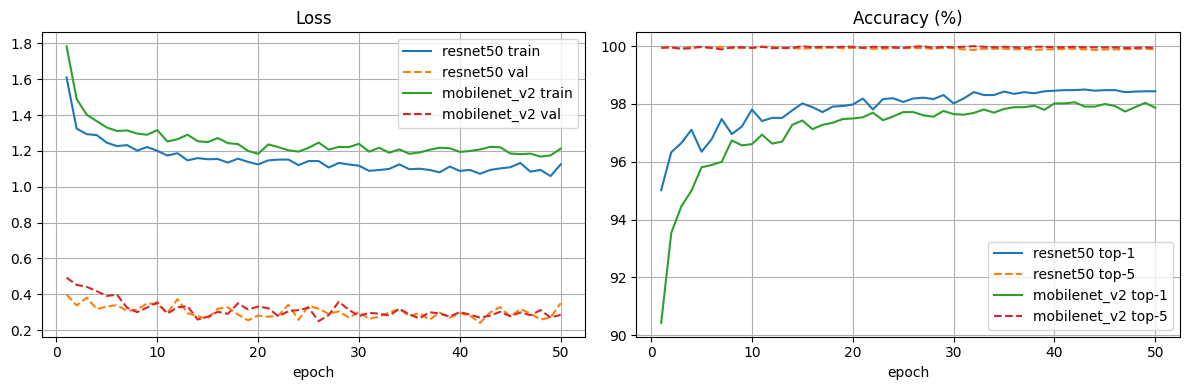

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['resnet50', 'mobilenet_v2']:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train')
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val', linestyle='--')
    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1')
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5', linestyle='--')
    print(f'{model_name}: best val top-1 = {df["val_top1"].max()*100:.2f}%')

axes[0].set_title('Loss');     axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_baselines.png', dpi=120)
plt.show()
